In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample

In [120]:
df = pd.read_csv('email_spam_500rows.csv')
df.head()

,email_id,sender,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam
0,1,sister@hotmail.com,32.0,0,0,323,0,4,0,0
1,2,hr@techcorp.com,20.0,0,0,333,3,1,0,0
2,3,professor@school.edu,15.0,0,1,237,2,1,0,0
3,4,noreply@github.com,36.0,1,0,241,2,4,0,0
4,5,friend@email.com,44.0,1,0,291,2,5,0,0


In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   email_id           500 non-null    int64  
 1   sender             500 non-null    str    
 2   subject_length     479 non-null    float64
 3   has_links          500 non-null    int64  
 4   has_images         500 non-null    int64  
 5   word_count         500 non-null    int64  
 6   exclamation_marks  500 non-null    int64  
 7   all_caps_words     500 non-null    int64  
 8   urgent_keywords    500 non-null    int64  
 9   is_spam            500 non-null    int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 39.2 KB


In [122]:
df.isnull().sum()

email_id              0
sender                0
subject_length       21
has_links             0
has_images            0
word_count            0
exclamation_marks     0
all_caps_words        0
urgent_keywords       0
is_spam               0
dtype: int64

In [123]:
df.describe()

,email_id,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam
count,500.000000,479.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,55.407098,0.740000,0.514000,168.242000,4.966000,8.300000,0.500000,0.500000
std,144.481833,22.137816,0.439074,0.500305,120.196897,3.922195,6.577578,0.500501,0.500501
min,1.000000,15.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,125.750000,36.000000,0.000000,0.000000,60.000000,1.750000,2.000000,0.000000,0.000000
50%,250.500000,58.000000,1.000000,1.000000,127.000000,4.000000,6.500000,0.500000,0.500000
75%,375.250000,74.000000,1.000000,1.000000,279.000000,8.250000,14.000000,1.000000,1.000000
max,500.000000,95.000000,1.000000,1.000000,400.000000,12.000000,20.000000,1.000000,1.000000


In [124]:
df.drop_duplicates()

,email_id,sender,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam
0,1,sister@hotmail.com,32.0,0,0,323,0,4,0,0
1,2,hr@techcorp.com,20.0,0,0,333,3,1,0,0
2,3,professor@school.edu,15.0,0,1,237,2,1,0,0
3,4,noreply@github.com,36.0,1,0,241,2,4,0,0
4,5,friend@email.com,44.0,1,0,291,2,5,0,0
...,...,...,...,...,...,...,...,...,...,...
495,496,respond@quickly.net,95.0,1,0,99,9,18,1,1
496,497,limited@offer.com,63.0,1,0,84,10,19,1,1
497,498,verify@secure.net,90.0,1,1,88,9,14,1,1
498,499,CONGRATULATIONS@WINNER.NET,NaN,1,0,26,5,11,1,1


In [125]:
df['sender'] = df['sender'].str.strip().str.lower()

In [126]:
df

,email_id,sender,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam
0,1,sister@hotmail.com,32.0,0,0,323,0,4,0,0
1,2,hr@techcorp.com,20.0,0,0,333,3,1,0,0
2,3,professor@school.edu,15.0,0,1,237,2,1,0,0
3,4,noreply@github.com,36.0,1,0,241,2,4,0,0
4,5,friend@email.com,44.0,1,0,291,2,5,0,0
...,...,...,...,...,...,...,...,...,...,...
495,496,respond@quickly.net,95.0,1,0,99,9,18,1,1
496,497,limited@offer.com,63.0,1,0,84,10,19,1,1
497,498,verify@secure.net,90.0,1,1,88,9,14,1,1
498,499,congratulations@winner.net,NaN,1,0,26,5,11,1,1


In [127]:
df['subject_length'] = df['subject_length'].fillna(df['subject_length'].median())
df.head()

,email_id,sender,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam
0,1,sister@hotmail.com,32.0,0,0,323,0,4,0,0
1,2,hr@techcorp.com,20.0,0,0,333,3,1,0,0
2,3,professor@school.edu,15.0,0,1,237,2,1,0,0
3,4,noreply@github.com,36.0,1,0,241,2,4,0,0
4,5,friend@email.com,44.0,1,0,291,2,5,0,0


In [128]:
df['domain'] = df['sender'].str.split('@').str[1]
df.head()

,email_id,sender,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam,domain
0,1,sister@hotmail.com,32.0,0,0,323,0,4,0,0,hotmail.com
1,2,hr@techcorp.com,20.0,0,0,333,3,1,0,0,techcorp.com
2,3,professor@school.edu,15.0,0,1,237,2,1,0,0,school.edu
3,4,noreply@github.com,36.0,1,0,241,2,4,0,0,github.com
4,5,friend@email.com,44.0,1,0,291,2,5,0,0,email.com


In [129]:
df[['domain','is_spam']]

,domain,is_spam
0,hotmail.com,0
1,techcorp.com,0
2,school.edu,0
3,github.com,0
4,email.com,0
...,...,...
495,quickly.net,1
496,offer.com,1
497,secure.net,1
498,winner.net,1


In [130]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   email_id           500 non-null    int64  
 1   sender             500 non-null    str    
 2   subject_length     500 non-null    float64
 3   has_links          500 non-null    int64  
 4   has_images         500 non-null    int64  
 5   word_count         500 non-null    int64  
 6   exclamation_marks  500 non-null    int64  
 7   all_caps_words     500 non-null    int64  
 8   urgent_keywords    500 non-null    int64  
 9   is_spam            500 non-null    int64  
 10  domain             500 non-null    object 
dtypes: float64(1), int64(8), object(1), str(1)
memory usage: 43.1+ KB


In [131]:
feature = [
    'subject_length','has_links','has_images','word_count','exclamation_marks','all_caps_words',
    'urgent_keywords'
]

x = df[feature]

scaler = StandardScaler()
x[['subject_length','word_count','exclamation_marks','all_caps_words']] = scaler.fit_transform(df[['subject_length','word_count','exclamation_marks','all_caps_words']])
print(x.head())

   subject_length  has_links  has_images  word_count  exclamation_marks  \
0       -1.086111          0           0    1.288827          -1.267396   
1       -1.640344          0           0    1.372107          -0.501752   
2       -1.871275          0           1    0.572618          -0.756967   
3       -0.901367          1           0    0.605930          -0.756967   
4       -0.531879          1           0    1.022330          -0.756967   

   all_caps_words  urgent_keywords  
0       -0.654391                0  
1       -1.110943                0  
2       -1.110943                0  
3       -0.654391                0  
4       -0.502207                0  


In [132]:

y = df['is_spam']

In [133]:
x

,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords
0,-1.086111,0,0,1.288827,-1.267396,-0.654391,0
1,-1.640344,0,0,1.372107,-0.501752,-1.110943,0
2,-1.871275,0,1,0.572618,-0.756967,-1.110943,0
3,-0.901367,1,0,0.605930,-0.756967,-0.654391,0
4,-0.531879,1,0,1.022330,-0.756967,-0.502207,0
...,...,...,...,...,...,...,...
495,1.823611,1,0,-0.576648,1.029536,1.476184,1
496,0.345656,1,0,-0.701569,1.284750,1.628368,1
497,1.592680,1,1,-0.668257,1.029536,0.867448,1
498,0.114726,1,0,-1.184593,0.008677,0.410897,1


In [134]:
df[[
    'subject_length','has_links','has_images','word_count','exclamation_marks','all_caps_words',
    'urgent_keywords','is_spam'
]].corr()

,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords,is_spam
subject_length,1.000000,0.459525,-0.058700,-0.728330,0.722843,0.719994,0.819895,0.819895
has_links,0.459525,1.000000,-0.083747,-0.515345,0.523167,0.516955,0.592749,0.592749
has_images,-0.058700,-0.083747,1.000000,0.001526,-0.029884,-0.033554,-0.036014,-0.036014
word_count,-0.728330,-0.515345,0.001526,1.000000,-0.787837,-0.803060,-0.901241,-0.901241
exclamation_marks,0.722843,0.523167,-0.029884,-0.787837,1.000000,0.800103,0.883553,0.883553
all_caps_words,0.719994,0.516955,-0.033554,-0.803060,0.800103,1.000000,0.888145,0.888145
urgent_keywords,0.819895,0.592749,-0.036014,-0.901241,0.883553,0.888145,1.000000,1.000000
is_spam,0.819895,0.592749,-0.036014,-0.901241,0.883553,0.888145,1.000000,1.000000


In [135]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [136]:
m1 = LogisticRegression()
m1.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [137]:
m2 = DecisionTreeClassifier()
m2.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [138]:
m3 = RandomForestClassifier()
m3.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [139]:
#Logistics
y_pred = m1.predict(x_test)

a1 = accuracy_score(y_test,y_pred)
p1 = precision_score(y_test,y_pred)
re1 = recall_score(y_test,y_pred)
f1_1 = f1_score(y_test,y_pred)

print(f'Accuracy: {a1:.2f}')
print(f'Precision: {p1:.2f}')
print(f'Recall: {re1:.2f}')
print(f'F1 score: {f1_1:.2f}')

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 score: 1.00


In [140]:
#Logistics
y_pred = m2.predict(x_test)

a2 = accuracy_score(y_test,y_pred)
p2 = precision_score(y_test,y_pred)
re2 = recall_score(y_test,y_pred)
f1_2 = f1_score(y_test,y_pred)

print(f'Accuracy: {a2:.2f}')
print(f'Precision: {p2:.2f}')
print(f'Recall: {re2:.2f}')
print(f'F1 score: {f1_2:.2f}')

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 score: 1.00


In [141]:
#Logistics
y_pred = m3.predict(x_test)

a3 = accuracy_score(y_test,y_pred)
p3 = precision_score(y_test,y_pred)
re3 = recall_score(y_test,y_pred)
f1_3 = f1_score(y_test,y_pred)

print(f'Accuracy: {a3:.2f}')
print(f'Precision: {p3:.2f}')
print(f'Recall: {re3:.2f}')
print(f'F1 score: {f1_3:.2f}')

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 score: 1.00


In [142]:
x

,subject_length,has_links,has_images,word_count,exclamation_marks,all_caps_words,urgent_keywords
0,-1.086111,0,0,1.288827,-1.267396,-0.654391,0
1,-1.640344,0,0,1.372107,-0.501752,-1.110943,0
2,-1.871275,0,1,0.572618,-0.756967,-1.110943,0
3,-0.901367,1,0,0.605930,-0.756967,-0.654391,0
4,-0.531879,1,0,1.022330,-0.756967,-0.502207,0
...,...,...,...,...,...,...,...
495,1.823611,1,0,-0.576648,1.029536,1.476184,1
496,0.345656,1,0,-0.701569,1.284750,1.628368,1
497,1.592680,1,1,-0.668257,1.029536,0.867448,1
498,0.114726,1,0,-1.184593,0.008677,0.410897,1


In [144]:
comparison = pd.DataFrame({
    'Model' : ['Logistic Regression','Decision Tree','Random Froest'],
    'Accuracy': [a1,a2,a3],
    'Precision': [p1,p2,p3],
    'Recall': [re1,re2,re3],
    'F1 Score': [f1_1,f1_2,f1_3]
})

print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0
2        Random Froest       1.0        1.0     1.0       1.0


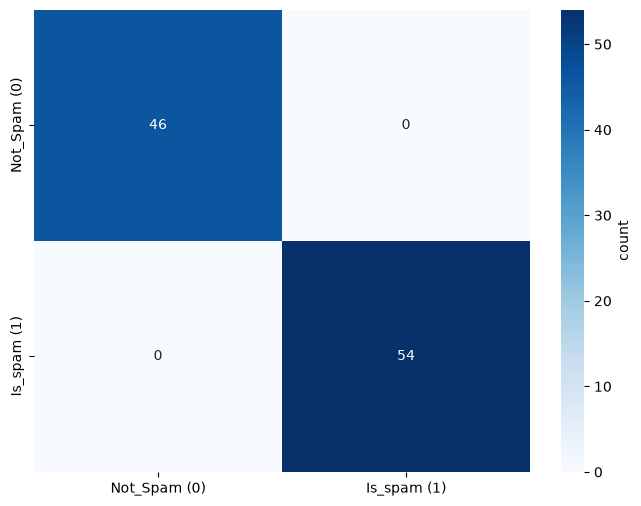

In [147]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Not_Spam (0)','Is_spam (1)'],
            yticklabels=['Not_Spam (0)','Is_spam (1)'],
            cbar_kws={'label':'count'})

plt.show()